In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => Temperature
# VT => vacuum
# AP => Pressure
# RH => Humidity

# PE => Produced Energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

## STEPS FOR IMPLEMENTING THE ANN FOP REGRESSION
- Load the data
- Data --> Tensors
- Tensor Dataset & DataLoader
- Define ANN model
- Train the Model
- save the model
- Evaluate

In [9]:
# SPLIT OUT DATA

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X_train

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [11]:
df.shape

(9568, 5)

In [12]:
# SCALING THE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [14]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [15]:
import torch
import torch.nn as nn

In [16]:
# Convert scaled data into the TENSOR

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)


X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)



In [17]:
type(X_train_scaled)

numpy.ndarray

In [18]:
type(y_train)

pandas.core.series.Series

In [19]:
# TENSOR-DATASET & DATALOADER 
# TENSOR-DATASET SYNTAX -----> TensorDataset(in_features, out_features)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [20]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # shuffle - DATA COMING SHUFFLE
test_loader = DataLoader(test_dataset, batch_size=32)

# Deep Learning 
- Defined the ANN Model

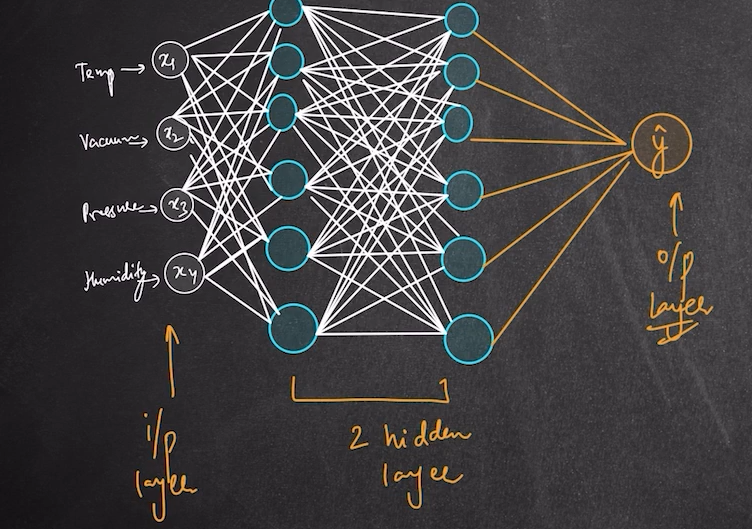

In [28]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model = nn.Sequential(

            # 1ST Hidden Layer: syntax --> nn.Linear(in_features, out_features)
            nn.Linear(X_train.shape[1], 6), # (9568, 5)[1], hidden layers
            nn.ReLU(),

            # 2ST Hidden Layer: syntax --> nn.Linear(in_features, out_features)
            nn.Linear(6, 6), # number of input 6 and output 6
            nn.ReLU(),
            
            # Outpur Layer
            nn.Linear(6, 1), # 6 inputs & 1 output
        )
    
    # This is Forward propagation.
    def forward(self, x): 
        return self.model(x)
    
    # The backward propagation (nn.backword) is handled by the AUTOGRADE automatically.

In [29]:
# Define Loss function and Optimizer

import torch.optim as optim

# Define the ANN Model
model = ANN()

# Define loss function which is - MEAN SQUARE ERROR
crietrion = nn.MSELoss()

# Define Optimizer - ADAM
optimizer = optim.Adam(model.parameters()) # Parameters like - Bias, Weight that already inbuild into "nn.Module()"


## Train The ANN Model

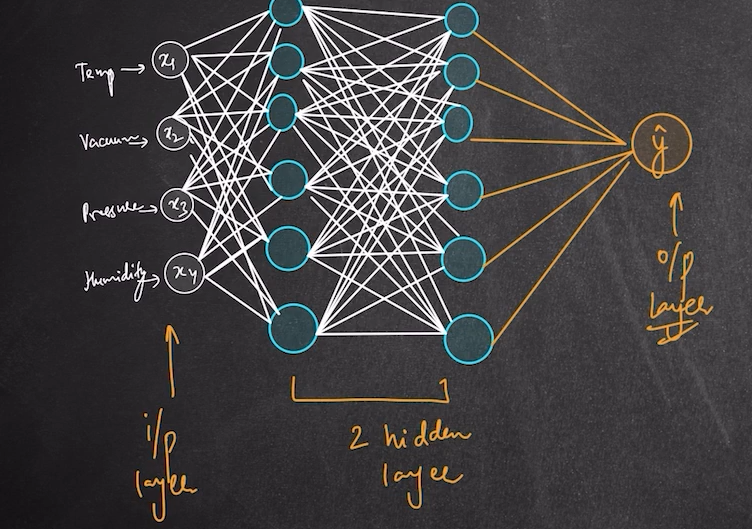

In [25]:
# Store the training losses
train_losses = []

# Store the Validation losses
val_losses = []

# Define the number of Epochs
epochs = 100

for epoch in range(epochs):
    model.train() # Why Train, because model already train the but now we are updating "WEIGHTS"

    # Calculate the per batch loss, total training loss for 1 epoch
    running_loss = 0.0
    
    for xb, yb in train_loader:
        # xb => features (input) of 1 batch
        # yb => labels of 1 batch

        # Clear (reset) all previously stored gradients before computing new ones.
        optimizer.zero_grad()
        
        outputs = model(xb) # Forward Propagation, predicted outputs for this batch  # Give the output based on the input(xb)
        loss = crietrion(outputs, yb) # Compute the Loss
        loss.backward() # Backword Propagation, compute gradient 
        optimizer.step() # update the parameter like "Bias & Weights"

        # Convert the Loss is TENSOR value because they are calculate by PYTORCH so that convert into "PY FLOAT"
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- Calculate The validation Losses---
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # Mean no gradients compute like not updating the Bias and Weights
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss
            
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1} / {epochs} ===> Train Loss = {epoch_train_loss} & Validation Loss = {epoch_val_loss}")

Epoch 1 / 100 ===> Train Loss = 20.46616736650467 & Validation Loss = 18.61617660522461
Epoch 2 / 100 ===> Train Loss = 20.572915335496265 & Validation Loss = 19.634225845336914
Epoch 3 / 100 ===> Train Loss = 20.438299266497292 & Validation Loss = 19.00540542602539
Epoch 4 / 100 ===> Train Loss = 20.559564677874246 & Validation Loss = 18.617786407470703
Epoch 5 / 100 ===> Train Loss = 20.456361265977225 & Validation Loss = 18.928457260131836
Epoch 6 / 100 ===> Train Loss = 20.48965781331062 & Validation Loss = 18.66341781616211
Epoch 7 / 100 ===> Train Loss = 20.517850323518118 & Validation Loss = 19.067899703979492
Epoch 8 / 100 ===> Train Loss = 20.534667499860127 & Validation Loss = 18.840375900268555
Epoch 9 / 100 ===> Train Loss = 20.38165280421575 & Validation Loss = 19.785505294799805
Epoch 10 / 100 ===> Train Loss = 20.43317126830419 & Validation Loss = 20.358922958374023
Epoch 11 / 100 ===> Train Loss = 20.439786183834077 & Validation Loss = 19.114187240600586
Epoch 12 / 100 

# Plot the Graph

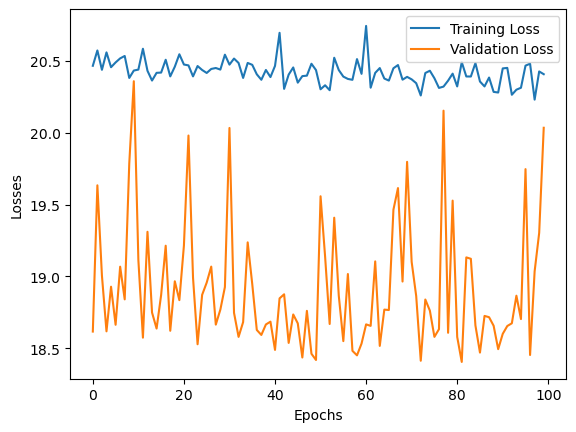

In [26]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame (
    {
        "Training Loss": train_losses,
        "Validation Loss": val_losses
    }
)

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()


## Saving & Loading Best Model

In [31]:
# Store the training losses
train_losses = []

# Store the Validation losses
val_losses = []

# ---------- Store the best validation loss -------------------
best_val_loss = float("inf") # inf ==> INFINITY

# Define the number of Epochs
epochs = 100

for epoch in range(epochs):
    model.train() # Why Train, because model already train the but now we are updating "WEIGHTS"

    # Calculate the per batch loss, total training loss for 1 epoch
    running_loss = 0.0
    
    for xb, yb in train_loader:
        # xb => features (input) of 1 batch
        # yb => labels of 1 batch

        # Clear (reset) all previously stored gradients before computing new ones.
        optimizer.zero_grad()
        
        outputs = model(xb) # Forward Propagation, predicted outputs for this batch  # Give the output based on the input(xb)
        loss = crietrion(outputs, yb) # Compute the Loss
        loss.backward() # Backword Propagation, compute gradient 
        optimizer.step() # update the parameter like "Bias & Weights"

        # Convert the Loss is TENSOR value because they are calculate by PYTORCH so that convert into "PY FLOAT"
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- Calculate The validation Losses---
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # Mean no gradients compute like not updating the Bias and Weights
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss
            
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1} / {epochs} ===> Train Loss = {epoch_train_loss} & Validation Loss = {epoch_val_loss}")

    # ---- SAVIING & LOADING BEST MODEL-----
    if epoch_val_loss < best_val_loss:
        epoch_val_loss = best_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt OR .pth

Epoch 1 / 100 ===> Train Loss = 21.48677917321523 & Validation Loss = 19.541255950927734
Epoch 2 / 100 ===> Train Loss = 21.40916372934977 & Validation Loss = 19.72284698486328
Epoch 3 / 100 ===> Train Loss = 21.3227330327034 & Validation Loss = 19.947696685791016
Epoch 4 / 100 ===> Train Loss = 21.260517919063567 & Validation Loss = 19.710111618041992
Epoch 5 / 100 ===> Train Loss = 21.40837965408961 & Validation Loss = 19.647451400756836
Epoch 6 / 100 ===> Train Loss = 21.39206211666266 & Validation Loss = 19.665210723876953
Epoch 7 / 100 ===> Train Loss = 21.420999300479888 & Validation Loss = 19.573972702026367
Epoch 8 / 100 ===> Train Loss = 21.389340794086458 & Validation Loss = 19.740514755249023
Epoch 9 / 100 ===> Train Loss = 21.32553332646688 & Validation Loss = 19.552953720092773
Epoch 10 / 100 ===> Train Loss = 21.3605011900266 & Validation Loss = 19.81578254699707
Epoch 11 / 100 ===> Train Loss = 21.495730630556743 & Validation Loss = 20.490819931030273
Epoch 12 / 100 ===>

## LOADING THE BEST MODEL

In [32]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## Evalute the ANN Regression Model:

In [34]:
# Convert into the evalution Mode:-
model.eval()

with torch.no_grad():
    # Prediction for the training and testing Tensor
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    # Calculate the MSE for training and testing data
    train_mse_loss = crietrion(train_preds, y_train_tensor) #SYNTAX -> criterion(predicted_output, actual_target)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE: ", train_mse_loss)
print("Testing MSE: ", test_mse_loss)

print("TENSOR CONVERT INTO FLOAT")
print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())

Training MSE:  tensor(21.1106)
Testing MSE:  tensor(19.6531)
TENSOR CONVERT INTO FLOAT
Training MSE:  21.11056900024414
Testing MSE:  19.653135299682617


In [35]:
# CALCULATE THE R^2 SCORE VALUE
from sklearn.metrics import r2_score

print("r^2 Score:", r2_score(y_test, test_preds))

r^2 Score: 0.931317364644954


# COMPARE THE ACTUAL AND PREDICTED VALUES

In [38]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df],axis=1)

,Predicted Values,Actual Values
0,435.882568,433.27
1,437.582977,438.16
2,461.738342,458.42
3,476.359863,480.82
4,436.539703,441.41
...,...,...
1909,451.377319,456.70
1910,432.330017,438.04
1911,467.695435,467.80
1912,431.887909,437.14
